# 🚢 Titanic Machine Learning Classification

## Visualization, Model Comparison & Kaggle Submission

The goal of this project is to build a **Machine Learning classification model** to predict whether a passenger survived the Titanic disaster.

The target variable is:

- `Survived = 0` → Did not survive
- `Survived = 1` → Survived

The project follows a simple CRISP-DM style workflow:

**Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation → Kaggle Submission**

The project includes data visualization, feature engineering, comparison of multiple classification algorithms, model evaluation, and prediction on the Titanic test dataset.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

## 2. Load Train and Test Data

In [4]:
train = pd.read_csv("ttrain.csv")
test = pd.read_csv("ttest.csv")

In [5]:
print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (891, 12)
Test shape : (418, 11)


In [6]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Data Understanding

The target variable is `Survived`.

- `0` = Did not survive
- `1` = Survived

In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [8]:
train.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

We can see that `Age`, `Cabin`, and `Embarked` contain missing values.

`Cabin` has many missing values, so we will not use it in this simple model.

## 4. Data Visualization

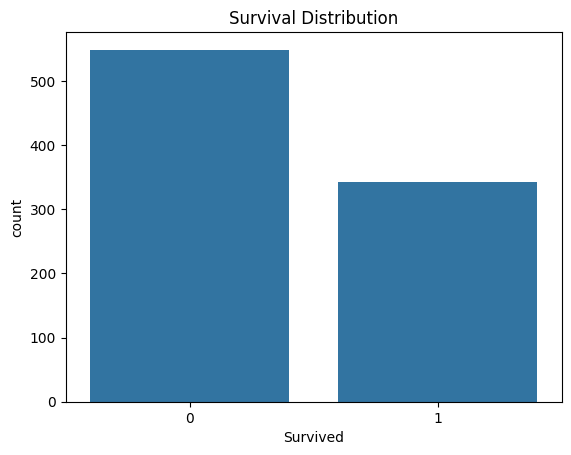

In [9]:
sns.countplot(data=train, x="Survived")
plt.title("Survival Distribution")
plt.show()

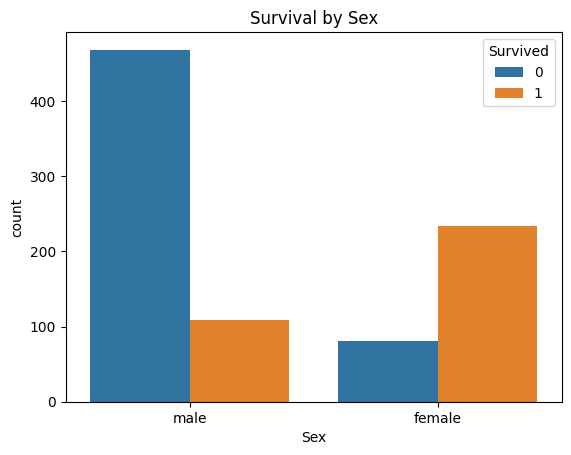

In [10]:
sns.countplot(data=train, x="Sex", hue="Survived")
plt.title("Survival by Sex")
plt.show()

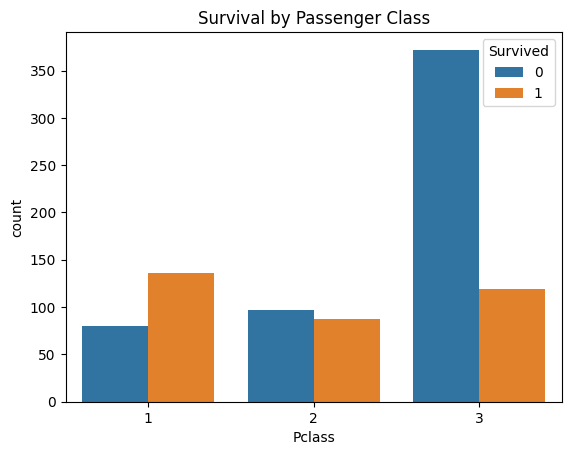

In [11]:
sns.countplot(data=train, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

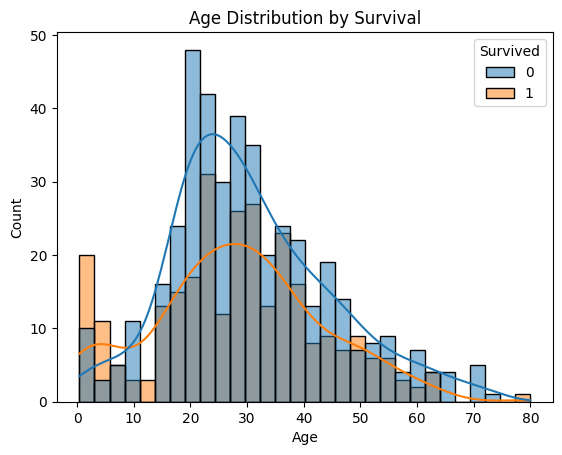

In [12]:
sns.histplot(data=train, x="Age", hue="Survived", bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.show()

### What do the visualizations suggest?

The graphs allow us to explore possible relationships between survival and passenger characteristics before modeling.

Survival appears to differ by **sex** and **passenger class**, while age also shows different patterns between the two survival groups.

## 5. Combine Train and Test Data

We combine both datasets temporarily so that the same data preparation is applied to both.

The original train/test identity is stored in a new `Dataset` column.

In [13]:
train["Dataset"] = "train"
test["Dataset"] = "test"

test["Survived"] = np.nan

all_data = pd.concat([train, test], ignore_index=True)

all_data.shape

(1309, 13)

## 6. Data Preparation

### Fill Missing Values

- `Age` → median
- `Fare` → median
- `Embarked` → most frequent value

In [14]:
all_data["Age"] = all_data["Age"].fillna(all_data["Age"].median())
all_data["Fare"] = all_data["Fare"].fillna(all_data["Fare"].median())
all_data["Embarked"] = all_data["Embarked"].fillna(all_data["Embarked"].mode()[0])

### Feature Engineering

We create three simple features:

- `FamilySize` = passenger + siblings/spouse + parents/children
- `IsAlone` = whether the passenger is travelling alone
- `Title` = title extracted from the passenger name, such as Mr, Mrs, Miss, or Master

In [15]:
all_data["FamilySize"] = all_data["SibSp"] + all_data["Parch"] + 1

all_data["IsAlone"] = (all_data["FamilySize"] == 1).astype(int)

all_data["Title"] = all_data["Name"].str.extract(
    r",\s*([^.]*)\.",
    expand=False
).str.strip()

main_titles = ["Mr", "Mrs", "Miss", "Master"]

all_data["Title"] = all_data["Title"].where(
    all_data["Title"].isin(main_titles),
    "Rare"
)

In [16]:
all_data["Title"].value_counts()

Title
Mr        757
Miss      260
Mrs       197
Master     61
Rare       34
Name: count, dtype: int64

### Select Features

We keep useful and easy-to-explain variables.

`PassengerId`, `Name`, `Ticket`, and `Cabin` are not used directly as model inputs.

In [17]:
model_data = all_data[[
    "Dataset",
    "PassengerId",
    "Survived",
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title"
]].copy()

### Convert Categorical Variables

Machine learning models need numerical inputs.

We convert `Sex`, `Embarked`, and `Title` with `pd.get_dummies()`.

In [18]:
model_data = pd.get_dummies(
    model_data,
    columns=["Sex", "Embarked", "Title"],
    drop_first=True,
    dtype=int
)

model_data.head()

,Dataset,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,train,1,0.0,3,22.0,1,0,7.2500,2,0,1,0,1,0,1,0,0
1,train,2,1.0,1,38.0,1,0,71.2833,2,0,0,0,0,0,0,1,0
2,train,3,1.0,3,26.0,0,0,7.9250,1,1,0,0,1,1,0,0,0
3,train,4,1.0,1,35.0,1,0,53.1000,2,0,0,0,1,0,0,1,0
4,train,5,0.0,3,35.0,0,0,8.0500,1,1,1,0,1,0,1,0,0


## 7. Separate Train and Kaggle Test Data Again

In [19]:
train_ready = model_data[model_data["Dataset"] == "train"].copy()
test_ready = model_data[model_data["Dataset"] == "test"].copy()

x = train_ready.drop(columns=["Dataset", "PassengerId", "Survived"])
y = train_ready["Survived"].astype(int)

x_kaggle = test_ready.drop(columns=["Dataset", "PassengerId", "Survived"])
passenger_ids = test_ready["PassengerId"].astype(int)

print("x shape       :", x.shape)
print("x_kaggle shape:", x_kaggle.shape)

x shape       : (891, 14)
x_kaggle shape: (418, 14)


## 8. Train / Validation Split

In [20]:
x_train, x_val, y_train, y_val = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data  :", x_train.shape)
print("Validation data:", x_val.shape)

Training data  : (712, 14)
Validation data: (179, 14)


## 9. Scale the Data

Scaling puts numerical features on a similar scale and is especially useful for models such as Logistic Regression and K-Nearest Neighbors.

In [21]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)

## 10. Algorithm Selection

We test several classification algorithms that are also commonly used in introductory machine learning projects.

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [23]:
results = []

for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    prediction = model.predict(x_val_scaled)

    accuracy = accuracy_score(y_val, prediction)
    results.append([name, accuracy])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy"]
).sort_values("Accuracy", ascending=False)

results_df

,Model,Accuracy
0,Logistic Regression,0.854749
3,Random Forest,0.832402
1,K-Nearest Neighbors,0.815642
4,Gradient Boosting,0.815642
2,Decision Tree,0.798883


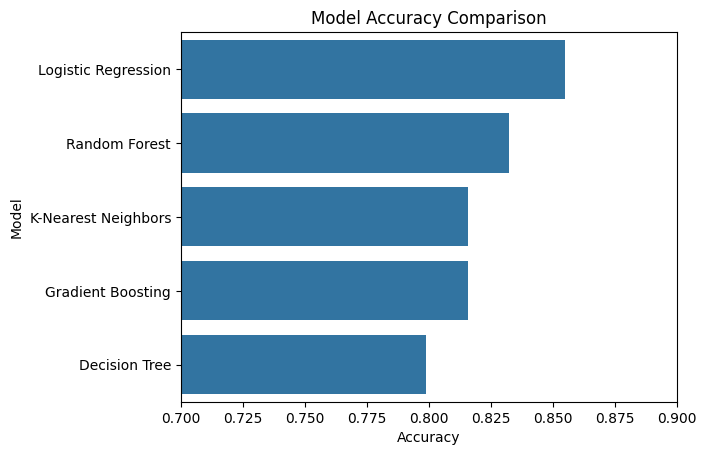

In [24]:
sns.barplot(data=results_df, x="Accuracy", y="Model")
plt.title("Model Accuracy Comparison")
plt.xlim(0.70, 0.90)
plt.show()

## 11. Best Model

In [25]:
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]

print("Best model:", best_name)
print("Validation accuracy:", round(results_df.iloc[0]["Accuracy"], 4))

Best model: Logistic Regression
Validation accuracy: 0.8547


## 12. Model Evaluation

In [26]:
best_prediction = best_model.predict(x_val_scaled)

print("Accuracy:", round(accuracy_score(y_val, best_prediction), 4))
print()
print(classification_report(y_val, best_prediction))

Accuracy: 0.8547

              precision    recall  f1-score   support

           0       0.86      0.91      0.88       110
           1       0.84      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



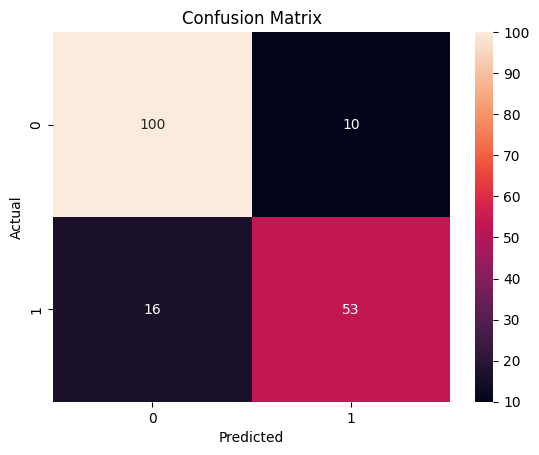

In [27]:
cm = confusion_matrix(y_val, best_prediction)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 13. Train the Best Model on All Training Data

After evaluating the algorithms, we train the selected model again using all available labeled Titanic training data.

In [28]:
final_scaler = StandardScaler()

x_full_scaled = final_scaler.fit_transform(x)
x_kaggle_scaled = final_scaler.transform(x_kaggle)

final_model = clone(models[best_name])
final_model.fit(x_full_scaled, y)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## 14. Predict the Kaggle Test Dataset

In [29]:
kaggle_prediction = final_model.predict(x_kaggle_scaled).astype(int)

submission = pd.DataFrame({
    "PassengerId": passenger_ids.values,
    "Survived": kaggle_prediction
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


## 15. Create Submission File

In [30]:
submission.to_csv("titanic_kaggle_submission.csv", index=False)

print("Submission file created.")
print("Rows:", len(submission))

Submission file created.
Rows: 418


## 16. Project Summary

In this project, a complete **Machine Learning classification workflow** was developed to predict Titanic passenger survival.

The project included:

- Data understanding and visualization
- Missing value handling
- Feature engineering with `FamilySize`, `IsAlone`, and `Title`
- Categorical data conversion with `pd.get_dummies()`
- Train/validation split
- Feature scaling with `StandardScaler`
- Comparison of five classification algorithms
- Model evaluation using accuracy, classification report, and confusion matrix
- Retraining the selected model on all labeled training data
- Prediction on the Titanic test dataset
- Kaggle-ready submission file creation

Among the tested models, **Logistic Regression** achieved the best validation performance with an accuracy of approximately **85.5%**.

The final trained model was then used to generate predictions for all **418 passengers** in the Titanic test dataset and create the Kaggle submission file.

This project demonstrates the complete workflow from **data exploration and preparation to feature engineering, model comparison, evaluation, and final prediction**.